In [1]:
import sys
if "tf_env" not in sys.executable:
    print("/n环境配置错误!!!/n")
    print(sys.executable)
else:
    print("环境配置正常")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib import rcParams # 字体配置,支持中文
rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False  # 解决负号不显示的问题

import torch


环境配置正常


In [2]:
def tensor_print(t , num=0):
    print(f"{t} , type:{type(t)}" , end='')
    try:
        print(f' row:{t.shape[0]} , columns:{t.shape[1]} , last:{t.shape[-1]}')
    except Exception as e:
        print('t.shape:',t.shape)        
    if num != 0:
        print('-' * 15,end='')
        print(f' 第{num}项如上',end='')
        print('-' * 15)
    else:
        print('-'*30)

<font color = #000000 >

## 2-1 激活函数介绍

+ 对于隐藏层：
    1. 优先选择ReLU激活函数
    2. 如果ReLu效果不好，那么尝试其他激活，如LeakyReLu等。
    3. 如果你使用了ReLU，需要注意一下DeadReLU问题，避免出现0梯度从而导致过多的神经元死亡。
    4. 少使用sigmoid激活函数，可以尝试使用tanh激活函数

+ 对于输出层：
    1. 二分类问题选择sigmoid激活函数
    2. 多分类问题选择softmax激活函数
    3. 回归问题选择identity激活函数

+ 记忆: 如何选择激活函数
    + 隐藏层:
        + ReLU > Leaky ReLU > PReLU > Tanh > Sigmoid
    + 输出层:
        + 二分类: Sigmoid
        + 多分类: Softmax
        + 回归问题: identity

`各种函数介绍`
+ Sigmoid激活函数:
        主要应用于 二分类的输出层, 且适用于 浅层神经网络(不超过5层).
        数据在 [-6, 6]之间有效果, 在[-3, 3]之间效果明显, 会将数据值映射到: [0, 1]
        求导后范围在 [0, 0.25]

+ Tanh:
        主要应用于 隐藏层, 且适用于 浅层神经网络(不超过5层).
        数据在 [-3, 3]之间有效果, 在[-1, 1]之间效果明显, 会将数据值映射到: [-1, 1]
        求导后范围在 [0, 1], 较之于Sigmoid, 收敛速度快.

+ ReLU:
        计算公式为: max(0, x), 计算量相对较小, 训练成本低. 多应用于 隐藏层, 且适合 深层神经网络.
        求导后, 值要么是0, 要么是1, 较之于Tanh, 收敛速度更快.
        默认情况下ReLU只考虑 正样本, 可以使用LeakyReLU, PReLU 来考虑 正负样本. 

+ Softmax:
        将多分类的结果以概率的形式展示, 且概率和相加为1, 最终选取概率值最大的分类 作为最终结果.

</font>

<font color = #000000 >

### 2-5-1 sigmoid函数

+ `一般来说，sigmoid网络在5层之内就会产生梯度消失现象。而且，该激活函数并不是以0为中心的，所以在实践中这种激活函数使用的很少。sigmoid函数一般只用于二分类的输出层。`

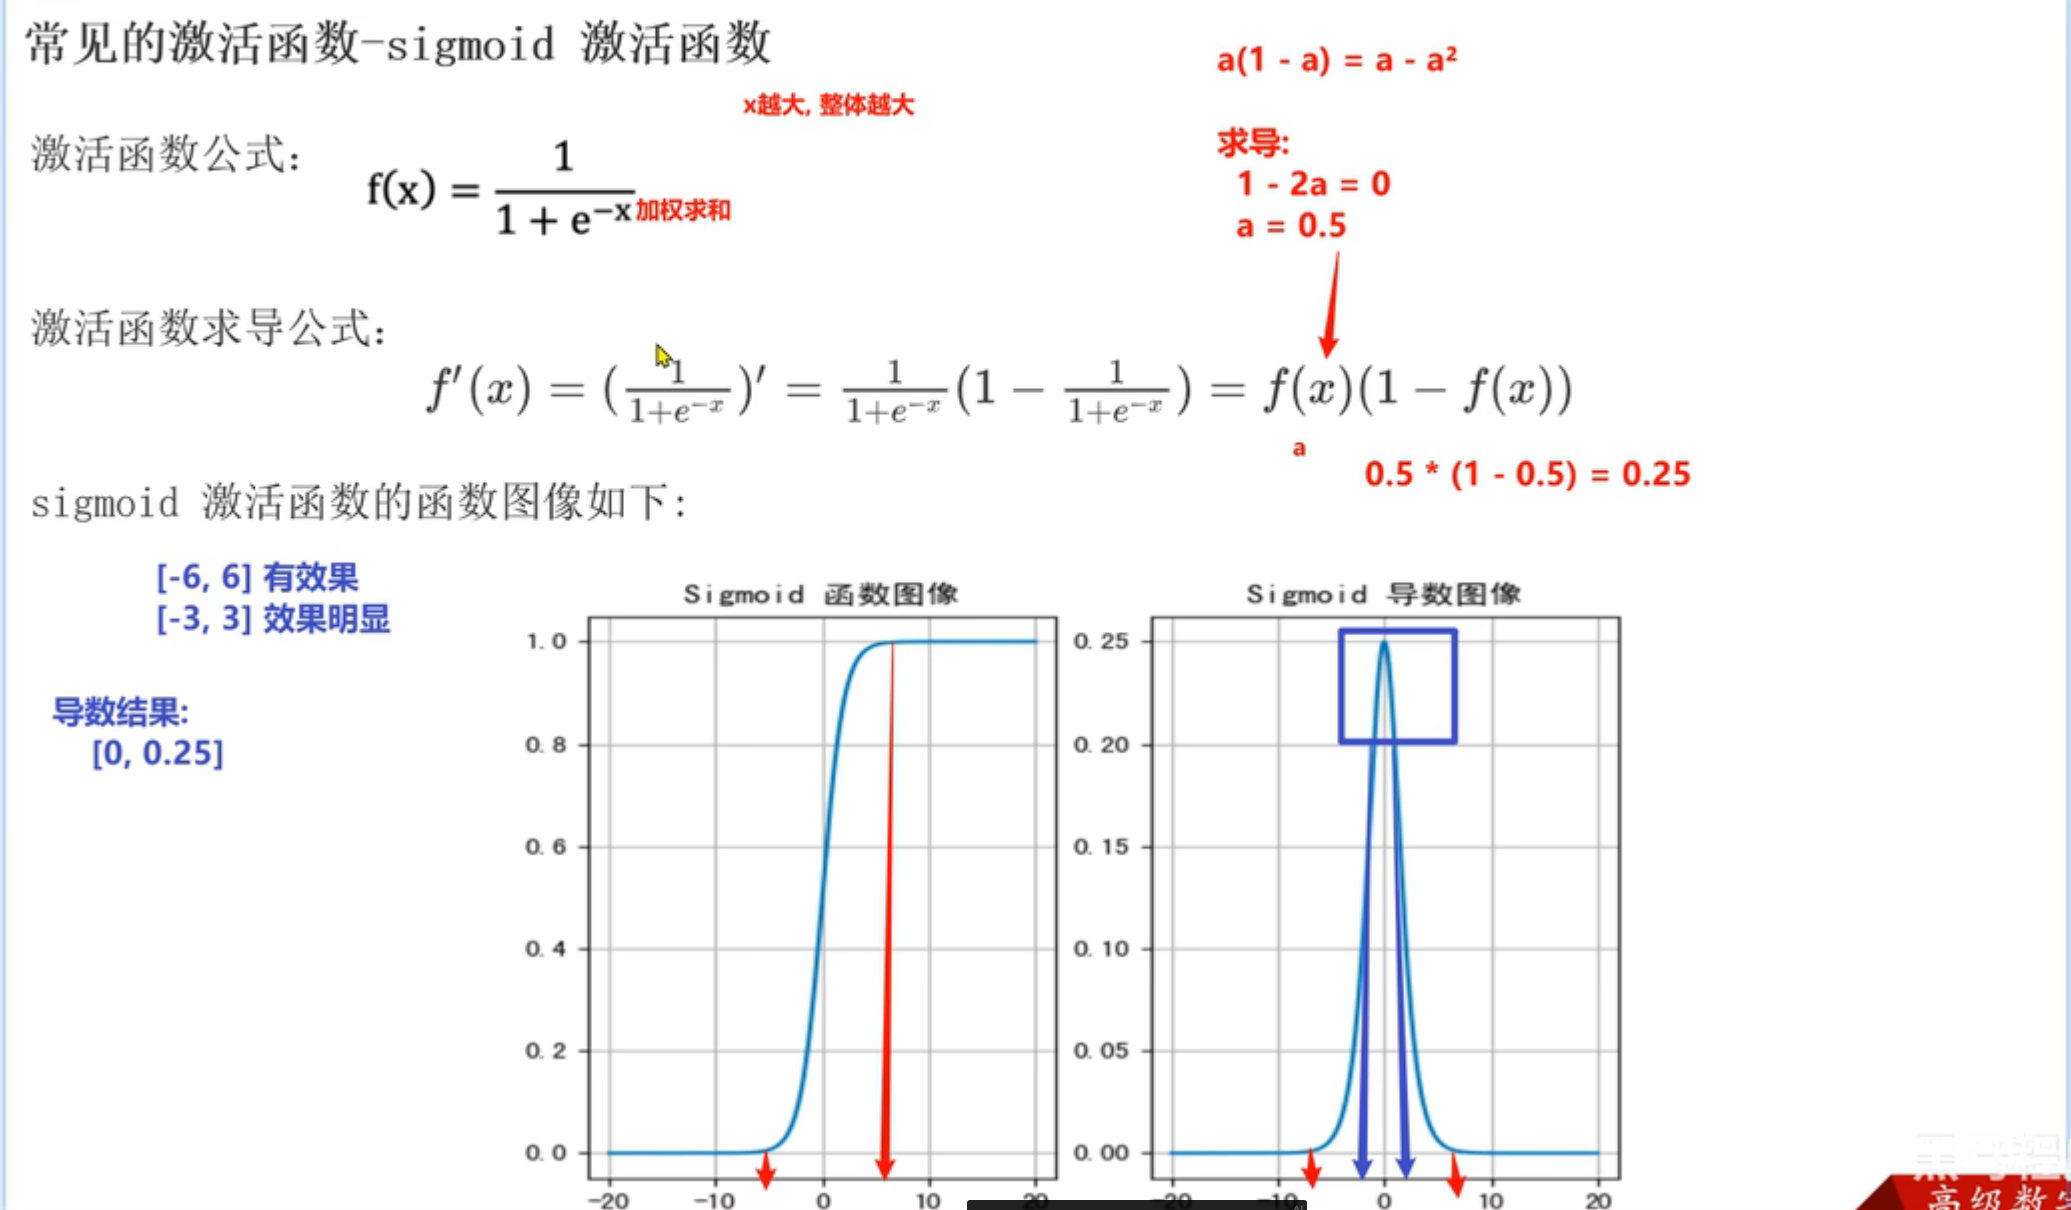

</font>

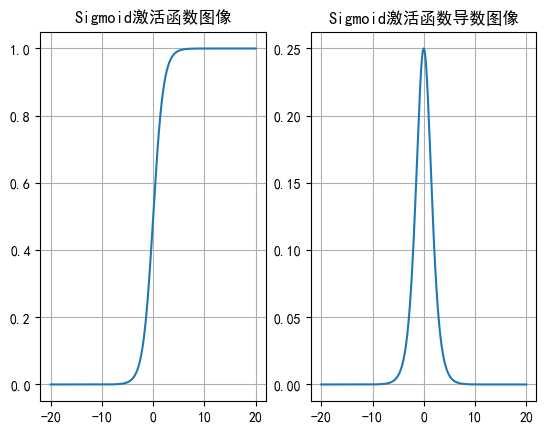

In [3]:
# 绘制Sigmoid图解
# 1. 创建画布和坐标轴, 1行2列.
fig, axes = plt.subplots(1, 2)

# 2. 生成 -20 ~ 20之间的 1000个数据点.
x = torch.linspace(-20, 20, 1000)
# print(f'x: {x}')

# 3. 计算上述1000个点, Sigmoid激活函数处理后的值.
y = torch.sigmoid(x)
# print(f'y: {y}')

# 4. 在第1个子图中绘制Sigmoid激活函数的图像.
axes[0].plot(x, y)
axes[0].set_title('Sigmoid激活函数图像')
axes[0].grid()

# 5. 在第2个图上, 绘制Sigmoid激活函数的导数图像.
# 5.1 重新生成 -20 ~ 20之间的 1000个数据点.
# 参1: 起始值, 参2: 结束值, 参3: 元素的个数, 参4: 是否需要求导.
x = torch.linspace(-20, 20, 1000, requires_grad=True)

# 5.2 具体的计算上述1000个点, Sigmoid激活函数导数后的值.
torch.sigmoid(x).sum().backward()

# 5.3 绘制图像.
axes[1].plot(x.detach(), x.grad)
axes[1].set_title('Sigmoid激活函数导数图像')
axes[1].grid()
plt.show()

<font color = #000000 >

### 2-5-2 tanh函数

`若使用时可在隐藏层使用tanh函数，在输出层使用sigmoid函数。`

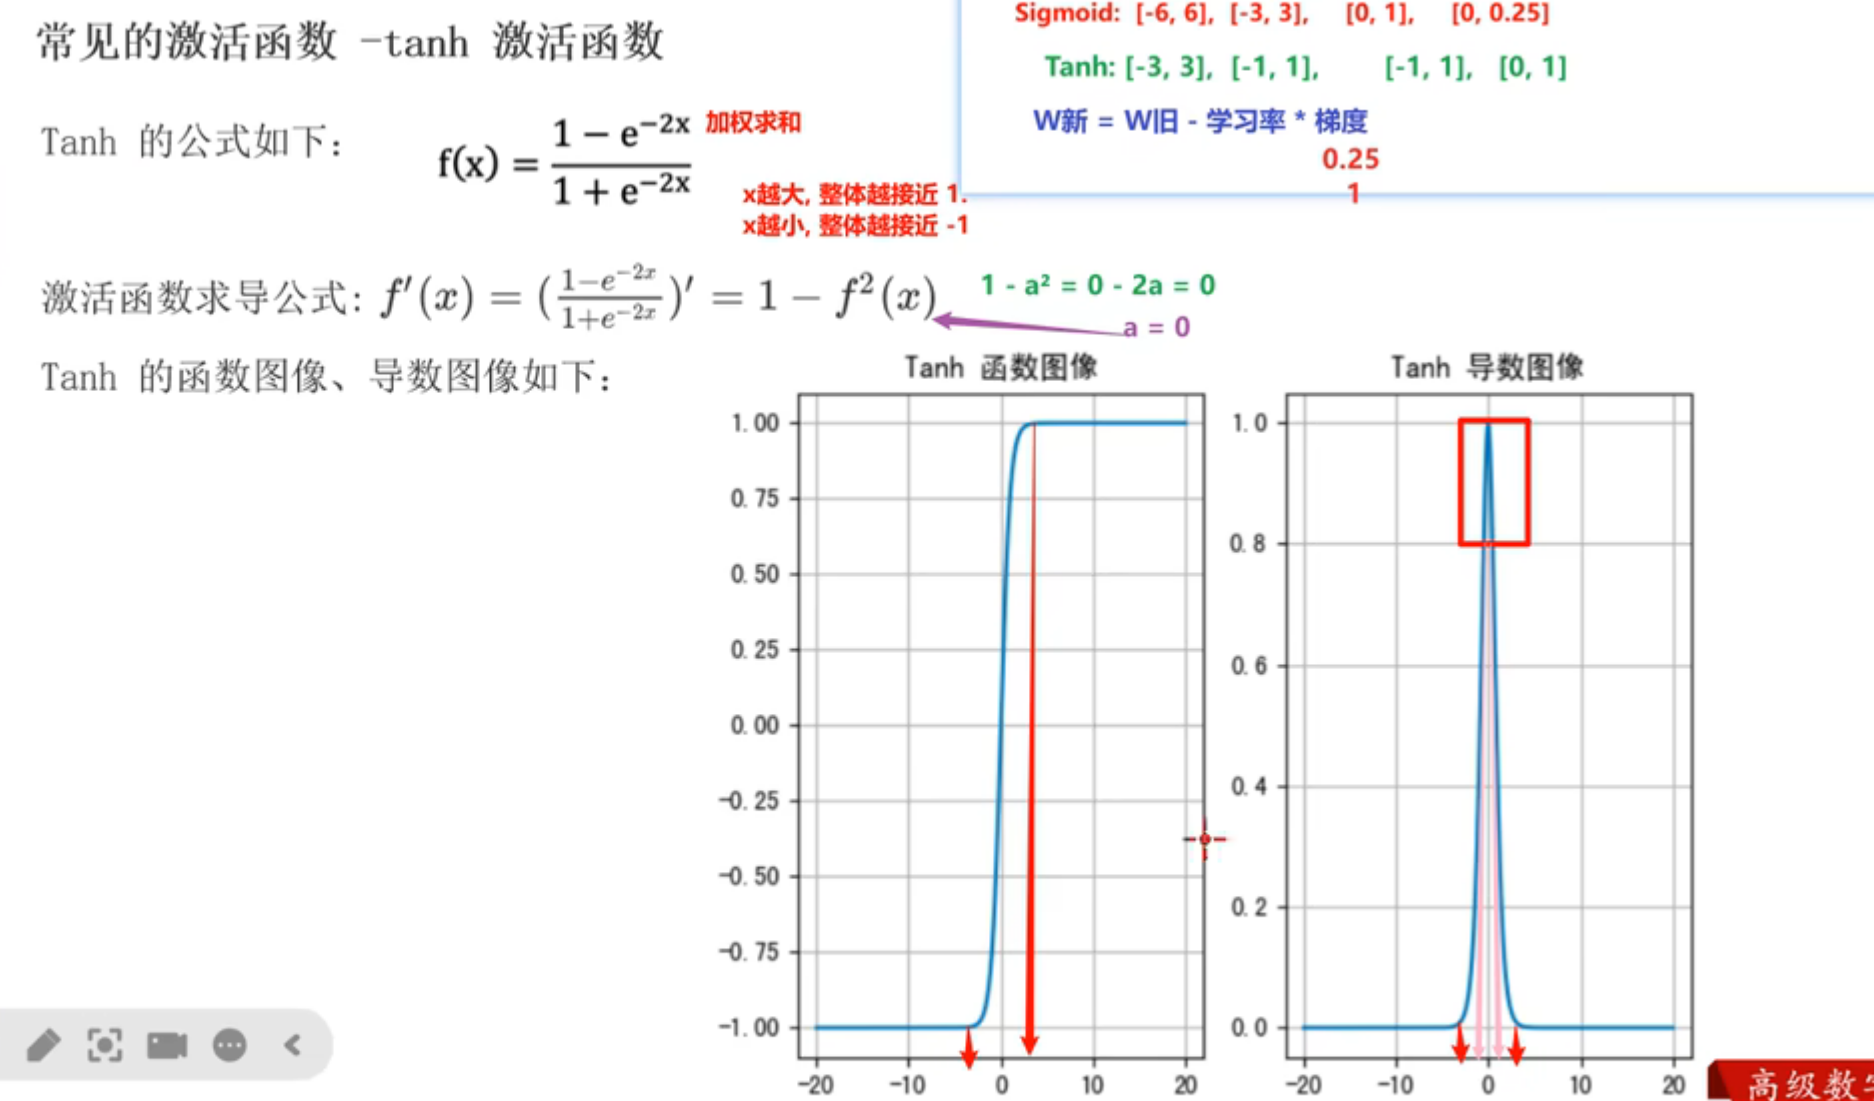

</font>

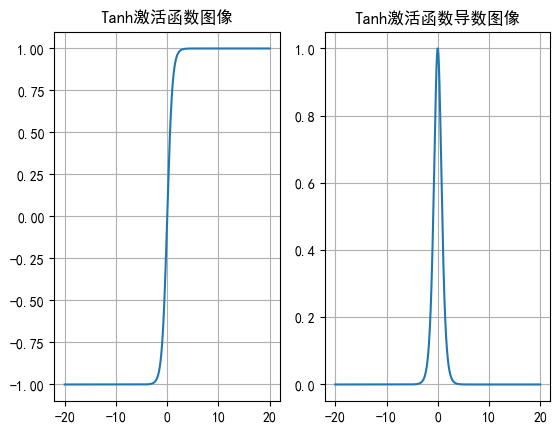

In [4]:
# 1. 创建画布和坐标轴, 1行2列.
fig, axes = plt.subplots(1, 2)

# 2. 生成 -20 ~ 20之间的 1000个数据点.
x = torch.linspace(-20, 20, 1000)
# print(f'x: {x}')

# 3. 计算上述1000个点, Tanh激活函数处理后的值.
y = torch.tanh(x)
# print(f'y: {y}')

# 4. 在第1个子图中绘制Tanh激活函数的图像.
axes[0].plot(x, y)
axes[0].set_title('Tanh激活函数图像')
axes[0].grid()

# 5. 在第2个图上, 绘制Tanh激活函数的导数图像.
# 5.1 重新生成 -20 ~ 20之间的 1000个数据点.
# 参1: 起始值, 参2: 结束值, 参3: 元素的个数, 参4: 是否需要求导.
x = torch.linspace(-20, 20, 1000, requires_grad=True)

# 5.2 具体的计算上述1000个点, Tanh激活函数导数后的值.
torch.tanh(x).sum().backward()

# 5.3 绘制图像.
axes[1].plot(x.detach(), x.grad)
axes[1].set_title('Tanh激活函数导数图像')
axes[1].grid()
plt.show()

<font color = #000000 >

### 2-5-3 ReLu函数

`默认情况下,只考虑正样本`

f(x) = max(0,x)

</font>

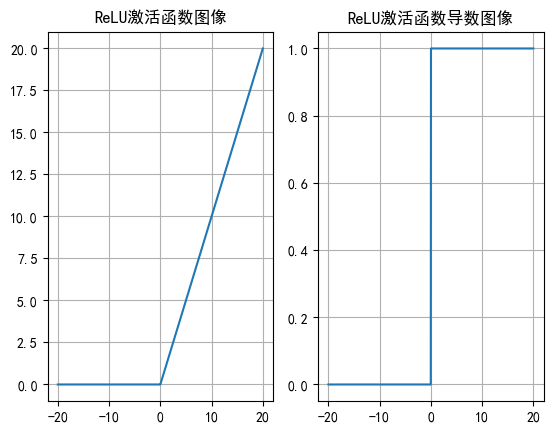

In [5]:
# 1. 创建画布和坐标轴, 1行2列.
fig, axes = plt.subplots(1, 2)

# 2. 生成 -20 ~ 20之间的 1000个数据点.
x = torch.linspace(-20, 20, 1000)
# print(f'x: {x}')

# 3. 计算上述1000个点, ReLU激活函数处理后的值.
y = torch.relu(x)
# print(f'y: {y}')

# 4. 在第1个子图中绘制ReLU激活函数的图像.
axes[0].plot(x, y)
axes[0].set_title('ReLU激活函数图像')
axes[0].grid()

# 5. 在第2个图上, 绘制ReLU激活函数的导数图像.
# 5.1 重新生成 -20 ~ 20之间的 1000个数据点.
# 参1: 起始值, 参2: 结束值, 参3: 元素的个数, 参4: 是否需要求导.
x = torch.linspace(-20, 20, 1000, requires_grad=True)

# 5.2 具体的计算上述1000个点, ReLU激活函数导数后的值.
torch.relu(x).sum().backward()

# 5.3 绘制图像.
axes[1].plot(x.detach(), x.grad)
axes[1].set_title('ReLU激活函数导数图像')
axes[1].grid()
plt.show()

<font color = #000000 >

### 2-5-4 SoftMax激活函数

+ `将多分类的结果以概率的形式展示,并且概率和为1,最终选择概率值最大的分类作为最终结果`


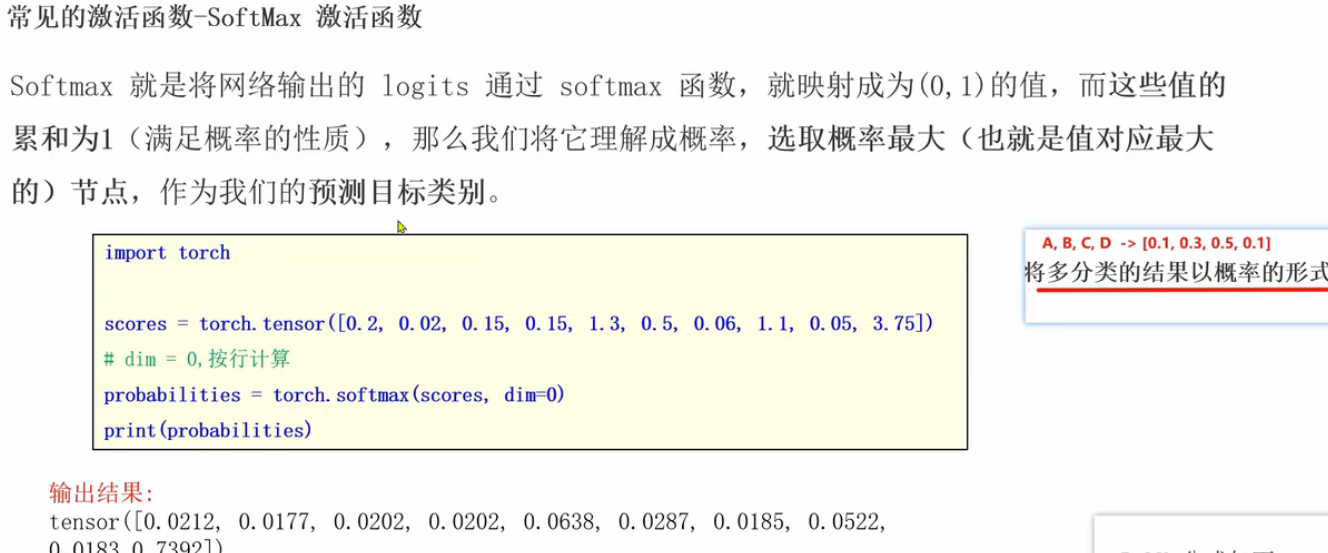

</font>

In [6]:
# 1. 定义张量, 记录: 分类数据.
# scores = torch.tensor([0.2, 0.02, 0.15, 0.15, 1.3, 0.5, 0.06, 1.1, 0.05, 3.75])
scores = torch.tensor([[0.2, 0.35, 0.1, 0.46], [0.1, 0.13, 0.05, 2.79]])
# 2. dim = 0, 按行计算
probabilities = torch.softmax(scores, dim=1)
print(probabilities)

tensor([[0.2292, 0.2663, 0.2074, 0.2972],
        [0.0565, 0.0582, 0.0537, 0.8317]])


<font color = #000000 >

## 2-2 参数初始化

`参数初始化`
+ 均匀分布初始化 (nn.init.uniform)
    + 权重参数初始化从区间均匀随机取值，默认区间为（0，1）。可以设置为在（-1/√d，1/√d)均匀分布中生成当前神经元的权重，其中d为神经元的输入数量
+ 正态分布初始化 (nn.init.normal)
    + 随机初始化从均值为0，标准差是1的高斯分布中取样，使用一些很小的值对参数W进行初始化
+ 全0初始化 (nn.init.zeros)
    + 将神经网络中的所有权重参数初始化为0
+ 全1初始化 (ones)
    + 将神经网络中的所有权重参数初始化为1
+ 固定值初始化 (constant)
    + 将神经网络中的所有权重参数初始化为某个固定值
+ kaiming初始化(搭配ReLU) 和 xavier初始化: 见最后的图片

`参数初始化的目的`
1. 防止梯度消失 或者 梯度爆炸.
2. 提高收敛速度.
3. 打破对称性.

+ 参数初始化的方式:
    + 无法打破对称性的:
        + 全0, 全1, 固定值
    + 可以打破对称性的:
        + 随机初始化, 正态分布初始化, kaiming初始化, xavier初始化

+ 总结:
    1. 记忆 kaiming初始化, xavier初始化, 全0初始化.
    2. 关于初始化的选择上:
        + 激活函数ReLU及其系列: 优先用 kaiming
        + 激活函数非ReLU: 优先用 xavier
        + 如果是浅层网络: 可以考虑使用 随机初始化

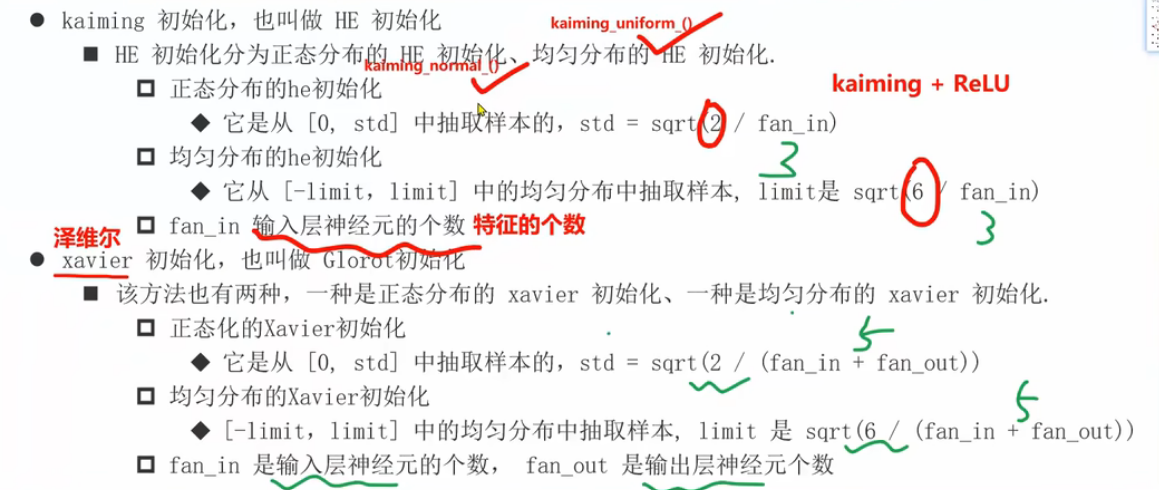

</font>

In [7]:
import torch.nn as nn

In [8]:
# 1. 均匀分布随机初始化

# 1-1 创建1个线性层 , 输入维度(特征)5 , 输出维度3
linear = nn.Linear(in_features=5 , out_features=3)
# 1-2 权重初始化, 从0-1均匀分布产生参数
nn.init.uniform_(linear.weight)
# 1-3 对偏置b进行随机初始化,从0-1均匀分布产生参数
nn.init.uniform_(linear.bias)   # 记得需要下划线版本,也就是直接改变.bias的值而不是还需要接收return值
# 1-4 打印生成结果
print(linear.weight)    
print(linear.bias.data) # .data只看数据,不看属性


Parameter containing:
tensor([[0.2082, 0.6204, 0.2541, 0.5313, 0.1368],
        [0.6484, 0.6278, 0.4583, 0.1404, 0.8237],
        [0.3859, 0.6781, 0.2588, 0.1703, 0.5322]], requires_grad=True)
tensor([0.6424, 0.5041, 0.1838])


In [9]:
# 2. 固定初始化

# 2-1 创建1个线性层 , 输入维度(特征)5 , 输出维度3
linear = nn.Linear(in_features=5 , out_features=3)
# 2-2 权重初始化, 从0-1均匀分布产生参数
nn.init.constant_(linear.weight , 3)
# 2-3 对偏置b进行随机初始化,从0-1均匀分布产生参数
nn.init.constant_(linear.bias , 2)   # 记得需要下划线版本,也就是直接改变.bias的值而不是还需要接收return值
# 2-4 打印生成结果
print(linear.weight)    
print(linear.bias.data) # .data只看数据,不看属性


Parameter containing:
tensor([[3., 3., 3., 3., 3.],
        [3., 3., 3., 3., 3.],
        [3., 3., 3., 3., 3.]], requires_grad=True)
tensor([2., 2., 2.])


In [10]:
# 3. 全0初始化
# 3-1. 创建1个线性层, 输入维度5, 输出维度3
linear = nn.Linear(5, 3)
# 3-2. 对权重(w)进行初始化, 全0初始化
nn.init.zeros_(linear.weight)
# 3-3. 对偏置(b)进行初始化, 全0初始化
nn.init.zeros_(linear.bias)
# 3-4. 打印生成结果.
print(linear.weight.data)
print(linear.bias.data)

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])
tensor([0., 0., 0.])


In [11]:
# 4. 全1初始化
# 4-1. 创建1个线性层, 输入维度5, 输出维度3
linear = nn.Linear(5, 3)
# 4-2. 对权重(w)进行初始化, 全1初始化
nn.init.ones_(linear.weight)
# 4-3. 打印生成结果.
print(linear.weight.data)


tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]])


In [12]:
# 5. 正态分布随机初始化
# 5-1. 创建1个线性层, 输入维度5, 输出维度3
linear = nn.Linear(5, 3)
# 5-2. 对权重(w)进行初始化, 正态分布初始化(均值为0, 标准差为1)
nn.init.normal_(linear.weight)
# 5-3. 打印生成结果.
print(linear.weight.data)

tensor([[-0.7024, -0.1060, -0.1257,  0.1557, -0.3220],
        [-2.5290,  0.2845, -0.6965,  1.0602, -0.4274],
        [ 0.0401,  0.1446,  0.5602, -0.9970,  0.7426]])


In [13]:
# 6. kaiming 初始化
# 6-1. 创建1个线性层, 输入维度5, 输出维度3
linear = nn.Linear(5, 3)
# 6-2. 对权重(w)进行初始化, 正态分布初始化(均值为0, 标准差为1)
# kaiming 正态分布初始化
# nn.init.kaiming_normal_(linear.weight)

# kaiming 均匀分布初始化
nn.init.kaiming_uniform_(linear.weight)

# 6-3. 打印生成结果.
print(linear.weight.data)

tensor([[-0.6362, -0.0188,  0.3702, -1.0907, -0.7560],
        [-0.4326,  1.0290,  0.0463,  0.0837, -0.0269],
        [-0.1992,  1.0457, -0.8296, -0.1073,  0.1508]])


In [14]:
# 7. xavier 初始化
# 7-1. 创建1个线性层, 输入维度5, 输出维度3
linear = nn.Linear(5, 3)
# 7-2. 对权重(w)进行初始化, 正态分布初始化(均值为0, 标准差为1)
# xavier 正态分布初始化
# nn.init.xavier_normal_(linear.weight)

# xavier 均匀分布初始化
nn.init.xavier_uniform_(linear.weight)

# 7-3. 打印生成结果.
print(linear.weight.data)

tensor([[-0.3240, -0.7806, -0.8603, -0.0347,  0.7549],
        [ 0.2781, -0.8605, -0.8072, -0.1002,  0.4304],
        [ 0.2915, -0.0546,  0.3784, -0.4206,  0.7834]])


<font color = #000000 >

## 2-3 神经网络搭建

+ 深度学习案例的4个步骤:
    1. 准备数据.
    2. 搭建神经网络
    3. 模型训练
    4. 模型测试

+ 神经网络搭建流程:
    1. 定义一个类, 继承: nn.Module
    2. 在__init__()方法中, 搭建神经网络(注意定义层的时候linear的in和out是相邻层的in和out而不是总模型的输入数和输出数).
    3. 在 forward()方法中(也是魔法方法,在实例化后,底层会自动调用),完成: 前向传播.


</font>

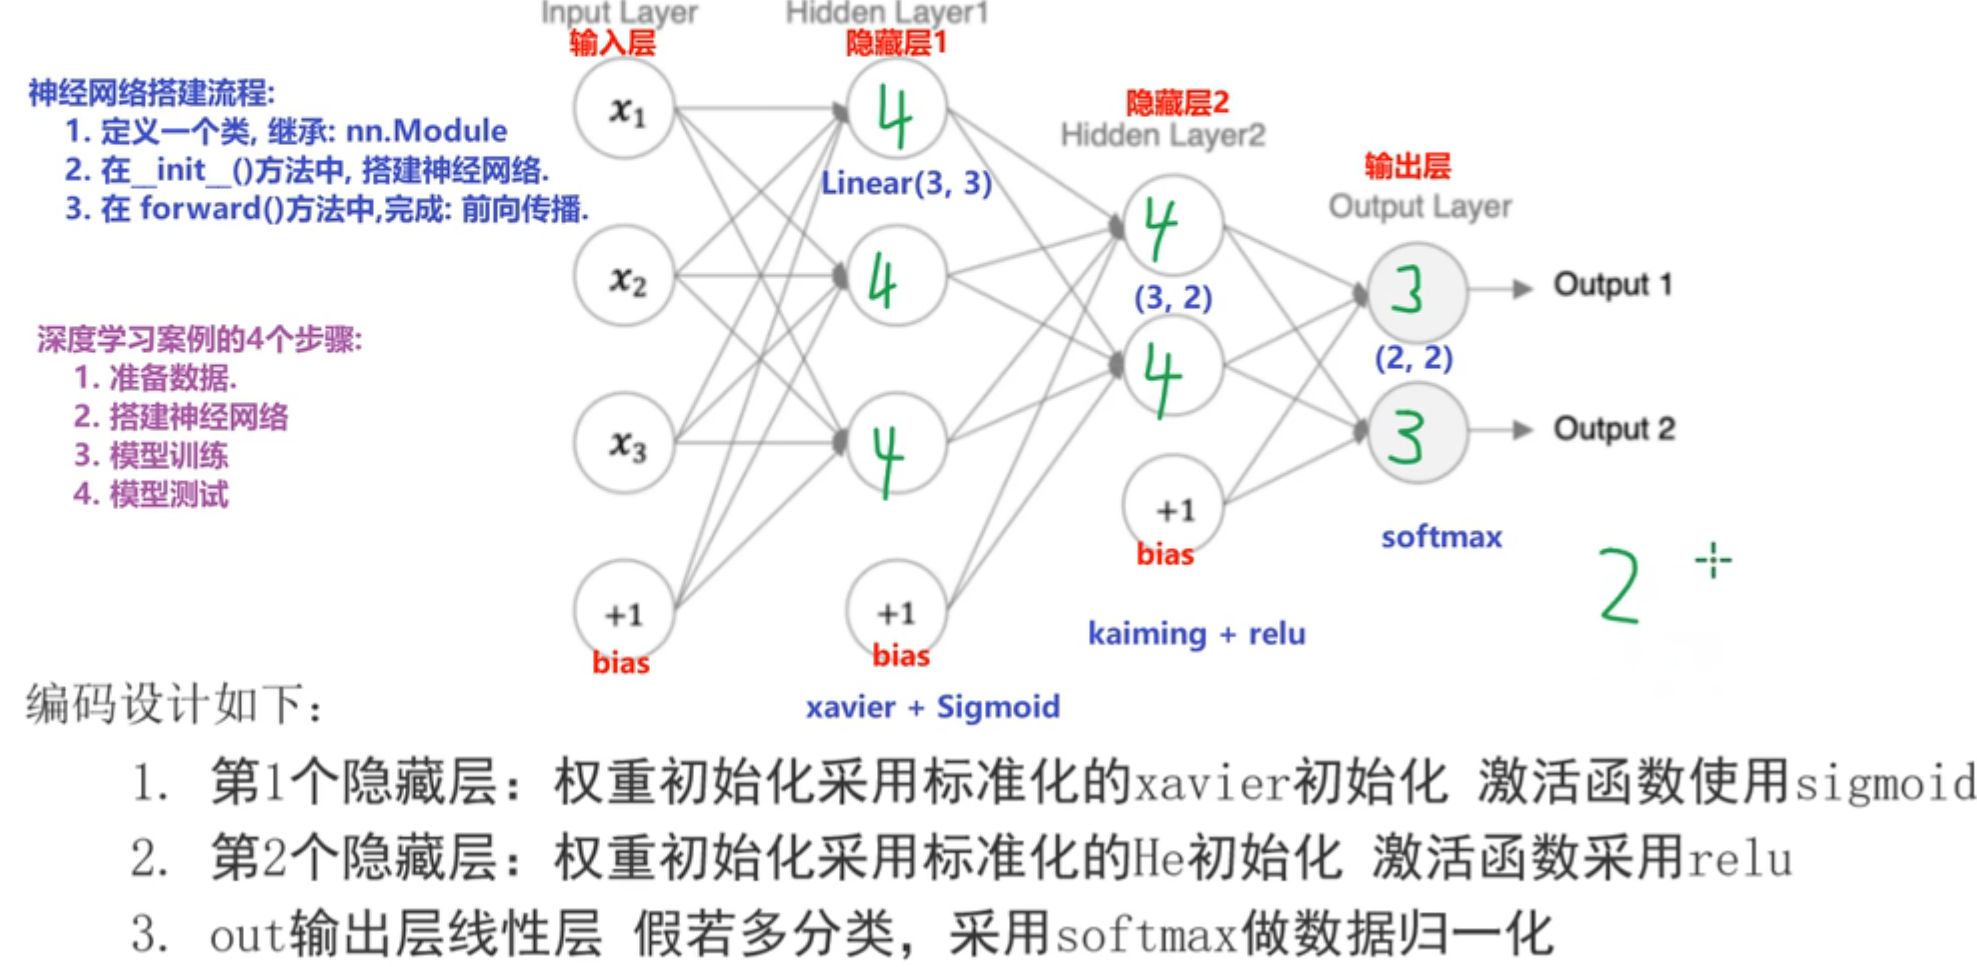

In [15]:
# 搭建一个神经网络
import torch
import torch.nn as nn
from torchsummary import summary

In [16]:
# 1. 搭建神经网络,自定义继承 nn.Module

class ModelDemo(nn.Module):
    '''
    核心步骤:
        1. 父类成员初始化
        2. 搭建神经网络:隐藏层 + 输出层
        3. 对隐藏层进行w/b初始化
    '''
    # 1. 在Init方法中完成初始化
    def __init__(self):
        # 1-1 初始化父类成员
        super().__init__()  # 里面不要放参数!
        # 1-2 搭建神经网络:隐藏层+输出层
        # 隐藏层1: in 3 out 3
        self.linear1 = nn.Linear(3,3)
        # 隐藏层2: in 3 out 3
        self.linear2 = nn.Linear(3,2)
        # 输出层 : in 2 out 2
        self.output  = nn.Linear(2,2)

        # 上面就是All了,下面底层会自动init

        # 1-3 对隐藏层进行参数(w/b)初始化
        # 隐藏层1
        nn.init.xavier_normal_(self.linear1.weight)
        nn.init.zeros_(self.linear1.bias)

        # 隐藏层2
        nn.init.kaiming_normal_(self.linear2.weight)
        nn.init.zeros_(self.linear2.bias)

    # 2. 前向传播: 输入层 -> 隐藏层 -> 输出层
    def forward(self , x):
        '''
        核心步骤:
            对各个层进行配置: 加权求和 + 激活函数(Sigmoid)
            返回计算结果(前向传播结果)
        '''
        # 2-1 第1层 隐藏层计算: 加权求和 + 激活函数(Sigmoid)
        # 写法1
        # x = self.linear1(x)     # 加权求和
        # x = torch.sigmoid(x)    # 激活函数

        # 写法2: 
        x = torch.sigmoid(self.linear1(x))   # 加权求和 + 激活函数

        # 2-2 第2层 隐藏层计算: 加权求和 + 激活函数(ReLU)
        x = torch.relu(self.linear2(x))   # 加权求和 + 激活函数

        # 2-3 第3层 输出层计算: 加权求和 + 激活函数(Softmax)
        # dim = -1 : 按行计算(一条一条样本的处理) dim = 0 : 按列计算
        x = torch.softmax(self.output(x) , dim=-1)   # 加权求和 + 激活函数

        # 2-4 返回
        return x 

In [17]:
# 3. 模型训练
def train() : 
    # 3-1 创建模型对象
    my_model = ModelDemo()
    # print(my_model)   # 可以查看模型的参数配置(in out isbias)
    # 3-2 创建数据集样本,随机生成
    data = torch.randn(size=(5,3))  # 3个特征(与列有关), 1批5条数据,每个数据都是3个特征,也就是x1,x2,x3
    # print(data)
    # print(data.shape)
    # print(data.requires_grad)   # False

    # 3-3 调用神经网络模型 -> 进行模型训练 (5条数据,每条都是3个特征(输入) , 所以得到2个输出,所以最终的output为5x2, 5条输出)
    output = my_model(data) # 实例化的时候会自动调用forward方法, 进行前向传播
    # print(output)
    # print(output.shape)
    # print(output.requires_grad)   # True

    # 3-4 计算和查看模型参数
    print('============== 查看模型参数 ==============')
    # my_model: 神经网络模型对象 , input_size: 输入数据的维度
    # summary(my_model , input_size=(5,3))
    for name , param in my_model.named_parameters():
        print('name:' , name)
        print('param:' , param)
        print('-' * 30)

In [18]:
# 4. 测试模型
train()

============== 查看模型参数 ==============
name: linear1.weight
param: Parameter containing:
tensor([[-0.4268,  0.0597,  0.0147],
        [ 1.0056, -0.0571,  0.3223],
        [-0.1755, -0.0272, -0.0937]], requires_grad=True)
------------------------------
name: linear1.bias
param: Parameter containing:
tensor([0., 0., 0.], requires_grad=True)
------------------------------
name: linear2.weight
param: Parameter containing:
tensor([[ 1.0265, -0.4451,  1.3081],
        [ 0.2529,  0.9290,  0.6631]], requires_grad=True)
------------------------------
name: linear2.bias
param: Parameter containing:
tensor([0., 0.], requires_grad=True)
------------------------------
name: output.weight
param: Parameter containing:
tensor([[-0.6370,  0.4892],
        [-0.4774,  0.1254]], requires_grad=True)
------------------------------
name: output.bias
param: Parameter containing:
tensor([-0.6570,  0.5421], requires_grad=True)
------------------------------


<font color = #000000 >

## 3-1 损失函数-多分类交叉熵损失

+ `真实概率就是只有正确值的y是1,其他的都是0`

+ `多分类任务交叉熵的模型可以不写最后输出的softmax处理,因为前者自己会做(nn.CrossEntropyLoss = softmax + 计算)`

<p align="left"><img src="激活函数和损失函数.assets/2026-03-17-21-25-45.png" style="width:60%;"></p>


</font>

In [19]:
# 分类损失函数 nn.CrossEntropyLoss = softmax + 计算
# 导包
import torch
import torch.nn as nn 

# 1. 手动创建样本真实值
# y_true = torch.tensor([[0,1,0] , [0,0,1]], dtype=torch.float)
y_true = torch.tensor([1,2])    # 2个样本,1个是1,1个是2

# 2. 手动创建样本的预测值 -> f(x)
y_pred = torch.tensor([[0.1 , 0.8, 0.1] , [0.7 , 0.2 ,0.1]] , requires_grad=True,dtype=torch.float) # 两个样本的预测概率

# 3. 创建多分类交叉熵损失函数
criterion = nn.CrossEntropyLoss()    # 计算平均损失

# 4. 计算损失值
loss = criterion(y_pred , y_true)
print(f'损失值:{loss}')

损失值:1.0288381576538086


<font color = #000000 >

## 3-2 损失函数-二分类任务损失函数

+ `不同于多分类函数的loss会自动进行softmax,二分类任务损失任务因为公式中没有包含Sigmoid激活函数，所以使用BCELoss的时候，还需要手动指定Sigmoid`

<p align="center"><img src="激活函数和损失函数.assets/2026-03-17-21-51-43.png" style="width:60%;"></p>

</font>

In [20]:
# 二分类任务的损失函数

# 1. 设置真实值(这里没有像上面的进行列表嵌套,所以表明每一个数据就是单个二分类真实结果(第1条为0,2为1,3为0))
y_true = torch.tensor([0,1,0] , dtype=torch.float)
# y_true = torch.tensor([[0],[1],[1]] , dtype=torch.float)

# 2. 设置预测值(概率),这里总和可以不是1,毕竟只是从模型训练抽出一部分观察损失值,所以和不为1也没啥
y_pred = torch.tensor([0.1,0.4,0.8])

# 3. 创建二分类交叉熵损失函数
criterion = nn.BCELoss()    # 底层也是计算平均损失

# 4. 计算损失值
loss = criterion(y_pred , y_true)
print(f'损失值:{loss}')


损失值:0.8770297169685364


<font color = #000000 >

## 3-3 损失函数-回归任务MAE损失函数

+ MAE也被成为L1 loss

<p align="center"><img src="激活函数和损失函数.assets/2026-03-17-22-01-27.png" style="width:60%;"></p>

</font>

In [21]:
# 回归任务损失函数: MAE

# 1. 设置真实值
y_true = torch.tensor([2.0,1.0,2.0] , dtype=torch.float)

# 2. 设置预测值(概率),这里总和可以不是1,毕竟只是从模型训练抽出一部分观察损失值,所以和不为1也没啥
y_pred = torch.tensor([2.0,1.0,2.8] , requires_grad=True)   # 需要可以求导

# 3. 创建二分类交叉熵损失函数
criterion = nn.L1Loss()  # MAE = L1loss

# 4. 计算损失值
loss = criterion(y_pred , y_true)
print(f'损失值:{loss}')


损失值:0.2666666507720947


<font color = #000000 >

## 3-4 损失函数-回归任务MSE损失函数

<p align="center"><img src="激活函数和损失函数.assets/2026-03-17-22-10-30.png" style="width:60%;"></p>

</font>

In [22]:
# 回归任务损失函数: MSE: 其实只修改了上面的 L1loss -> MSELoss

# 1. 设置真实值
y_true = torch.tensor([2.0,1.0,2.0] , dtype=torch.float)

# 2. 设置预测值(概率),这里总和可以不是1,毕竟只是从模型训练抽出一部分观察损失值,所以和不为1也没啥
y_pred = torch.tensor([2.0,1.0,2.8] , requires_grad=True)   # 需要可以求导

# 3. 创建二分类交叉熵损失函数
criterion = nn.MSELoss()

# 4. 计算损失值
loss = criterion(y_pred , y_true)
print(f'损失值:{loss}')


损失值:0.21333330869674683


<font color = #000000 >

## 3-5 损失函数-回归任务Smooth L1损失函数

<p align="center"><img src="激活函数和损失函数.assets/2026-03-17-22-12-30.png" style="width:60%;"></p>

</font>

In [23]:
# Smooth L1损失函数: SmoothL1Loss: 其实只修改了上面的 L1loss -> SmoothL1Loss

# 1. 设置真实值
y_true = torch.tensor([2.0,1.0,2.0] , dtype=torch.float)

# 2. 设置预测值(概率),这里总和可以不是1,毕竟只是从模型训练抽出一部分观察损失值,所以和不为1也没啥
y_pred = torch.tensor([2.0,1.0,2.8] , requires_grad=True)   # 需要可以求导

# 3. 创建二分类交叉熵损失函数
criterion = nn.SmoothL1Loss()

# 4. 计算损失值
loss = criterion(y_pred , y_true)
print(f'损失值:{loss}')



损失值:0.10666665434837341
